## Source: `Datacamp Projects`

# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops

![Farmer in a field](farmer_in_a_field.jpg)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.

A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:

- `"N"`: Nitrogen content ratio in the soil
- `"P"`: Phosphorous content ratio in the soil
- `"K"`: Potassium content ratio in the soil
- `"pH"` value of the soil
- `"crop"`: categorical values that contain various crops (target variable).

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  

In this project, you will build multi-class classification models to predict the type of `"crop"` and identify the `single most importance feature` for predictive performance.

In [124]:
# All required libraries are imported.
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load the dataset
crops = pd.read_csv("soil_measures.csv")


In [126]:
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [128]:
crops['crop'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

#### 22 unique output values for the target variable

In [130]:
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


##### No NULL values in the dataset

In [133]:
crops.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [135]:
crops.describe(include = 'object')

,crop
count,2200
unique,22
top,rice
freq,100


In [137]:
crops["crop"].value_counts()

crop
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

#### Equal distribution of all crop types - not a case of imbalanced class

Since are 22 different crop types we will encode these using `LabelEncoder`

In [141]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
crops['encoded_crop'] = encoder.fit_transform(crops['crop'])


In [143]:
crops

,N,P,K,ph,crop,encoded_crop
0,90,42,43,6.502985,rice,20
1,85,58,41,7.038096,rice,20
2,60,55,44,7.840207,rice,20
3,74,35,40,6.980401,rice,20
4,78,42,42,7.628473,rice,20
...,...,...,...,...,...,...
2195,107,34,32,6.780064,coffee,5
2196,99,15,27,6.086922,coffee,5
2197,118,33,30,6.362608,coffee,5
2198,117,32,34,6.758793,coffee,5


Encoded mapping for each crop type:

In [146]:
crop_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))


In [148]:
crop_mapping

{'apple': 0,
 'banana': 1,
 'blackgram': 2,
 'chickpea': 3,
 'coconut': 4,
 'coffee': 5,
 'cotton': 6,
 'grapes': 7,
 'jute': 8,
 'kidneybeans': 9,
 'lentil': 10,
 'maize': 11,
 'mango': 12,
 'mothbeans': 13,
 'mungbean': 14,
 'muskmelon': 15,
 'orange': 16,
 'papaya': 17,
 'pigeonpeas': 18,
 'pomegranate': 19,
 'rice': 20,
 'watermelon': 21}

In [150]:
df = crops.drop("crop", axis = 1)

In [152]:
df

,N,P,K,ph,encoded_crop
0,90,42,43,6.502985,20
1,85,58,41,7.038096,20
2,60,55,44,7.840207,20
3,74,35,40,6.980401,20
4,78,42,42,7.628473,20
...,...,...,...,...,...
2195,107,34,32,6.780064,5
2196,99,15,27,6.086922,5
2197,118,33,30,6.362608,5
2198,117,32,34,6.758793,5


### Since there are no null values or any other data cleaning required. We will head to data modeling to determine the best feature using the encoded dataset.

Here we will use `LogisticRegression` model and split our dataset into `X_train`, `X_test`, `y_train`, `y_test`

In [158]:
X = df.drop('encoded_crop', axis = 1)
y = df['encoded_crop']

In [160]:
X.head()

,N,P,K,ph
0,90,42,43,6.502985
1,85,58,41,7.038096
2,60,55,44,7.840207
3,74,35,40,6.980401
4,78,42,42,7.628473


In [162]:
y.head()

0    20
1    20
2    20
3    20
4    20
Name: encoded_crop, dtype: int32

In [164]:
#Running a for loop to evaluate each feature one by one. Here we will be to 80-20 split.
for feature in X.columns:

    X_feature = X[[feature]]

    # Splitting dataset into train/test
    X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=15)

    # Train logistic regression
    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)

    print(f"Feature: {feature} -> Test Accuracy: {accuracy:.4f}")

C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always

Feature: N -> Test Accuracy: 0.1136


C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Feature: P -> Test Accuracy: 0.1841
Feature: K -> Test Accuracy: 0.3000
Feature: ph -> Test Accuracy: 0.0795


C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The accuracies are very low --> Let's try using `StandardScaler` to normalize the values and see if that helps.

In [167]:
for feature in X.columns:

    X_feature = X[[feature]]

    # Using StandardScaler to normalize feature data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_feature)

    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=15)


    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)

    print(f"Feature: {feature} -> Test Accuracy: {accuracy:.4f}")

Feature: N -> Test Accuracy: 0.1159
Feature: P -> Test Accuracy: 0.1750
Feature: K -> Test Accuracy: 0.2591
Feature: ph -> Test Accuracy: 0.0818


C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

#### Let's check the f1 score for them

In [179]:
f1_scores = {}

for feature in X.columns:
    X_feature = X[[feature]]

    X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=42)

    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = metrics.f1_score(y_test, y_pred, average='weighted')
    f1_scores[feature] = f1

# Sort features based on highest to lowest score
sorted_scores = dict(sorted(f1_scores.items(), key=lambda x: x[1], reverse=True))
print("Feature F1 Scores:")
for feature, score in sorted_scores.items():
    print(f"{feature}: {score:.4f}")

C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always

Feature F1 Scores:
K: 0.2090
P: 0.1349
N: 0.1023
ph: 0.0458


C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sirja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


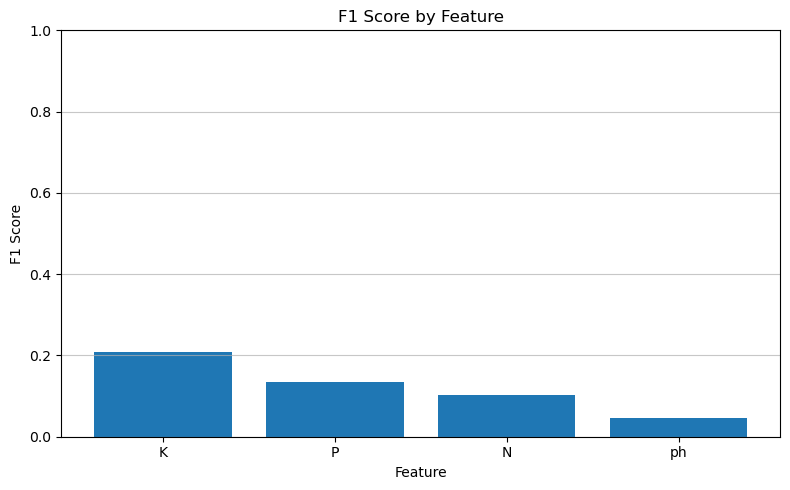

In [187]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.bar(sorted_scores.keys(), sorted_scores.values())
plt.title('F1 Score by Feature')
plt.xlabel('Feature')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

### Using LogisticRegression we see that `K` i.e. `Potassium` is the best feature to determine crop type (IF we only want to see a single feature)